In [ ]:
VOL_HL_SEC_DEFAULT = 30
SEASON_HL_S_DEFAULT = 180
TREND_HL_S_DEFAULT  = 5
SIGMOID_K_DEFAULT   = 10.0
EPS = 1e-12


In [ ]:
import numpy as np
import pandas as pd
from typing import Optional, Tuple, Dict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

EPS = 1e-12          # 防 0 除
CAP_Q = 0.995        # λ 上限 = 99.5% 分位 * 10
CAP_M = 10

def evaluate_volume_model_ema_se_benchmark(
        df: pd.DataFrame,
        lookahead: int,                  # 预测窗口 (秒)
        halflife: int,                   # EWMA 半衰期 (秒)
        alpha: float,                    # 自激强度
        decay: float,                    # 自激衰减 0<d<1
        bucket: int = 1,                 # 聚合桶长 (秒)
        side: Optional[str] = None,
) -> Tuple[pd.Series, pd.DataFrame, Optional[Dict[str, float]]]:
    
    if side == "buy":
        df = df[df.v > 0]
    elif side == "sell":
        df = df[df.v < 0]
    if df.empty:
        return pd.Series(dtype=float), pd.DataFrame(), None

    df = df.copy()
    df["datetime"] = pd.to_datetime(df.ts, unit="ms", utc=True)
    notional = (df.set_index("datetime")
                  .assign(n=lambda x: (x.p * x.v.abs()).abs())
                  .n.resample(f"{bucket}s").sum().fillna(0))

    hl_rows = max(1, int(np.ceil(halflife / bucket)))
    baseline = notional.ewm(halflife=hl_rows, adjust=False).mean()

    excess = (notional - baseline).clip(lower=0).values
    lam = np.zeros_like(excess)
    cap = notional.quantile(CAP_Q) * CAP_M
    for i in range(1, len(lam)):
        lam_i = np.log1p(alpha * excess[i-1]) + decay * lam[i-1]
        lam[i] = min(lam_i, cap)
    lam = pd.Series(lam, index=notional.index)

    L_rows = max(1, int(np.ceil(lookahead / bucket)))
    c = (1 - decay**L_rows) / (L_rows * (1 - decay + EPS))

    pred = baseline + lam * c
    true = (notional.shift(-L_rows)
                    .rolling(L_rows, min_periods=L_rows)
                    .mean())
    
    diff = (pred - true).fillna(0)

    aligned = (pd.DataFrame({"pred": pred, "true": true})
                 .replace([np.inf, -np.inf], np.nan)
                 .dropna())

    if aligned.empty:
        return notional, aligned, None

    log_true = np.log1p(aligned.true.clip(lower=EPS))
    log_pred = np.log1p(aligned.pred.clip(lower=EPS))
    metrics = dict(
        samples=len(aligned),
        MAE  = mean_absolute_error(log_true, log_pred),
        RMSE = mean_squared_error(log_true, log_pred, squared=False),
        R2   = r2_score(aligned.true, aligned.pred),
        alpha=alpha, decay=decay, halflife=halflife
    )

    return notional, diff, aligned, metrics


In [7]:
from typing import Optional, Tuple, Dict
import numpy as np, pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def _realized_vol(price: pd.Series,
                  hl_sec: int = VOL_HL_SEC_DEFAULT) -> pd.Series:
    """√EWMA(Δln P)² (秒级)"""
    ret = np.log(price.replace(0, np.nan)).diff()
    return ret.pow(2).ewm(halflife=hl_sec, adjust=False).mean().pow(0.5)


def _compute_baseline(
        Nt: pd.Series,
        price: Optional[pd.Series] = None,
        k: float = SIGMOID_K_DEFAULT,
        seasonal_hl: int = SEASON_HL_S_DEFAULT,
        trend_hl: int = TREND_HL_S_DEFAULT,
        vol_hl_sec: int = VOL_HL_SEC_DEFAULT) -> pd.Series:
    """b_t = (1-w_t)·seasonal + w_t·trend，w_t∈(0,1)"""
    seasonal = Nt.ewm(halflife=seasonal_hl, adjust=False).mean()
    trend    = Nt.ewm(halflife=trend_hl,   adjust=False).mean()

    if price is None or price.isna().all():
        w = pd.Series(0.5, index=Nt.index)
    else:
        sigma = _realized_vol(price, hl_sec=vol_hl_sec)
        med   = sigma.median()
        w = 1.0 / (1.0 + np.exp(-k * (sigma - med)))
        w = w.reindex_like(Nt).fillna(method="ffill").clip(0.05, 0.95)

    return (1 - w) * seasonal + w * trend

In [ ]:
def evaluate_volume_model_ema_se(
        df: pd.DataFrame,
        lookahead: int,
        halflife: int,
        alpha: float,
        decay: float,
        bucket: int = 1,
        side: Optional[str] = None,
        #  新增可调超参数
        seasonal_hl: int = SEASON_HL_S_DEFAULT,
        trend_hl:    int = TREND_HL_S_DEFAULT,
        k_sigmoid:   float = SIGMOID_K_DEFAULT,
        vol_hl_sec:  int = VOL_HL_SEC_DEFAULT,
        use_dynamic_baseline: bool = True,
) -> Tuple[pd.Series, pd.Series, pd.DataFrame, Optional[Dict[str, float]]]:
    
    if side == "buy":
        df = df[df.v > 0]
    elif side == "sell":
        df = df[df.v < 0]
    if df.empty:
        return pd.Series(dtype=float), pd.Series(dtype=float), pd.DataFrame(), None

    df = df.copy()
    df["datetime"] = pd.to_datetime(df.ts, unit="ms", utc=True)
    notional = (df.set_index("datetime")
                  .assign(n=lambda x: (x.p * x.v.abs()).abs())
                  .n.resample(f"{bucket}s").sum().fillna(0))

    if use_dynamic_baseline:
        price_sec = (df.set_index("datetime").p
                       .resample(f"{bucket}s").last().fillna(method="ffill"))
        baseline = _compute_baseline(
            notional,
            price_sec,
            k=k_sigmoid,
            seasonal_hl=seasonal_hl,
            trend_hl=max(1, int(np.ceil(trend_hl / bucket))),
            vol_hl_sec=vol_hl_sec
        )
    else:
        hl_rows = max(1, int(np.ceil(halflife / bucket)))
        baseline = notional.ewm(halflife=hl_rows, adjust=False).mean()

    excess = (notional - baseline).clip(lower=0)
    lam = np.zeros_like(excess.values)
    CAP = notional.quantile(0.995) * 10
    for i in range(1, len(lam)):
        lam_i = np.log1p(alpha * excess.iat[i - 1]) + decay * lam[i - 1]
        lam[i] = lam_i if lam_i < CAP else CAP
    lam = pd.Series(lam, index=notional.index)

    L_rows = max(1, int(np.ceil(lookahead / bucket)))
    c = (1 - decay ** L_rows) / (L_rows * (1 - decay + EPS))
    pred = baseline + lam * c

    true = (notional.shift(-L_rows)
                    .rolling(L_rows, min_periods=L_rows)
                    .mean())
    diff = (pred - true).fillna(0)

    aligned = (pd.DataFrame({"pred": pred, "true": true})
                 .replace([np.inf, -np.inf], np.nan)
                 .dropna())
    if aligned.empty:
        return notional, diff, aligned, None

    try:
        log_true = np.log1p(aligned.true.clip(lower=1e-12))
        log_pred = np.log1p(aligned.pred.clip(lower=1e-12))

        metrics = dict(
            samples=len(aligned),
            MAE  = mean_absolute_error(log_true, log_pred),
            RMSE = mean_squared_error(log_true, log_pred, squared=False),
            R2   = r2_score(aligned.true, aligned.pred),
            alpha=alpha, decay=decay, halflife=halflife,
            seasonal_hl=seasonal_hl,
            trend_hl=trend_hl,
            k_sigmoid=k_sigmoid,
            vol_hl_sec=vol_hl_sec,
            dynamic_baseline=use_dynamic_baseline
        )
    except Exception:
        metrics = None

    return notional, diff, aligned, metrics

In [9]:
import filegetter.filegetter as fgt
from datetime import datetime, timedelta
from typing import Optional, Tuple, Dict

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


dates = pd.date_range("2025-05-16", "2025-05-16", freq="D")
raw_list = []
for d in dates:
    ymd = d.strftime("%Y%m%d")
    try:
        raw = (fgt.get("binance", "swap", "btc-usdt", "trade", ymd,
                       machine="AWS-JP1")[["p", "v", "ts"]]
               .dropna(subset=["p", "v", "ts"]))
        raw_list.append(raw)
    except Exception as e:
        print(f"[FAIL] {ymd}: {e}")

week_df = pd.concat(raw_list, ignore_index=True)
print("Merged rows:", len(week_df))

loading... AWS-JP1_BINANCE_SWAP_BTC-USDT_TRADE_2025_05_16.hdf 
Merged rows: 2302880


In [ ]:
import pandas as pd, numpy as np, optuna, tqdm, sys
from typing import Dict, Any

week_df["datetime"] = pd.to_datetime(week_df.ts, unit="ms", utc=True)
df_train = week_df[week_df.datetime.dt.date < pd.to_datetime("2025-06-01").date()]
df_valid = week_df[week_df.datetime.dt.date >= pd.to_datetime("2025-06-01").date()]

def objective(trial: optuna.Trial) -> float:
    params: Dict[str, Any] = dict(
        halflife    = trial.suggest_int  ("halflife",     3,   120, log=True),
        alpha       = trial.suggest_float("alpha",      0.05, 5.0,  log=True),
        decay       = trial.suggest_float("decay",      0.80, 0.999),
        seasonal_hl = trial.suggest_int  ("seasonal_hl", 30,  600,  log=True),
        trend_hl    = trial.suggest_int  ("trend_hl",     2,   30),
        k_sigmoid   = trial.suggest_float("k_sigmoid",    1,   25,  log=True),
        vol_hl_sec  = trial.suggest_int  ("vol_hl_sec",  10,  120, log=True),
    )

    _, _, aligned, metrics = evaluate_volume_model_ema_se(
        df_train, lookahead=5, bucket=1, side=None,
        use_dynamic_baseline=True, **params
    )

    if metrics is None or metrics["samples"] < 300 or not np.isfinite(metrics["RMSE"]):
        raise optuna.TrialPruned()

    trial.report(metrics["RMSE"], step=0)      
    return metrics["RMSE"]

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=2025),
    pruner = optuna.pruners.HyperbandPruner(),          
)

for _ in tqdm.tqdm(range(200), desc="Optuna search"):
    study.optimize(objective, n_trials=1, n_jobs=1, catch=(optuna.exceptions.TrialPruned,))

print("Best RMSE :", study.best_value)
print("Best params:", study.best_params)

_, _, aligned_val, val_metrics = evaluate_volume_model_ema_se(
    df_valid, lookahead=2, bucket=1, side=None,
    use_dynamic_baseline=True, **study.best_params
)
print("Hold-out:", val_metrics)


[I 2025-06-23 16:25:58,926] A new study created in memory with name: no-name-72de73aa-bfc0-4a85-a5d1-3e7c7710a0e2
Optuna search: 100%|██████████| 200/200 [02:31<00:00,  1.32it/s]

Best RMSE : 1.3503772303285198
Best params: {'halflife': 11, 'alpha': 0.061963843539220555, 'decay': 0.8279305664586314, 'seasonal_hl': 30, 'trend_hl': 2, 'k_sigmoid': 21.238776499662738, 'vol_hl_sec': 12}
Hold-out: None


In [ ]:
lam_sec, diff_1, aligned_train, _ = evaluate_volume_model_ema_se(
    df_train,          
    lookahead = 5,
    bucket    = 1,
    side      = "Buy",
    use_dynamic_baseline = True,
    **study.best_params  
)

In [28]:
_

{'samples': 86390,
 'MAE': 1.068876496769579,
 'RMSE': 1.3503772303285198,
 'R2': 0.014357654684869381,
 'alpha': 0.061963843539220555,
 'decay': 0.8279305664586314,
 'halflife': 11,
 'seasonal_hl': 30,
 'trend_hl': 2,
 'k_sigmoid': 21.238776499662738,
 'vol_hl_sec': 12,
 'dynamic_baseline': True}

In [29]:
lam_sec, diff_2, aligned_train, val_metrics=evaluate_volume_model_ema_se_benchmark(week_df,5, 11, 0.061963843539220555, 0.8279305664586314, side="buy")


In [30]:
val_metrics

{'samples': 86389,
 'MAE': 1.4949718276846968,
 'RMSE': 1.915997774454707,
 'R2': 0.03827433250650025,
 'alpha': 0.061963843539220555,
 'decay': 0.8279305664586314,
 'halflife': 11}

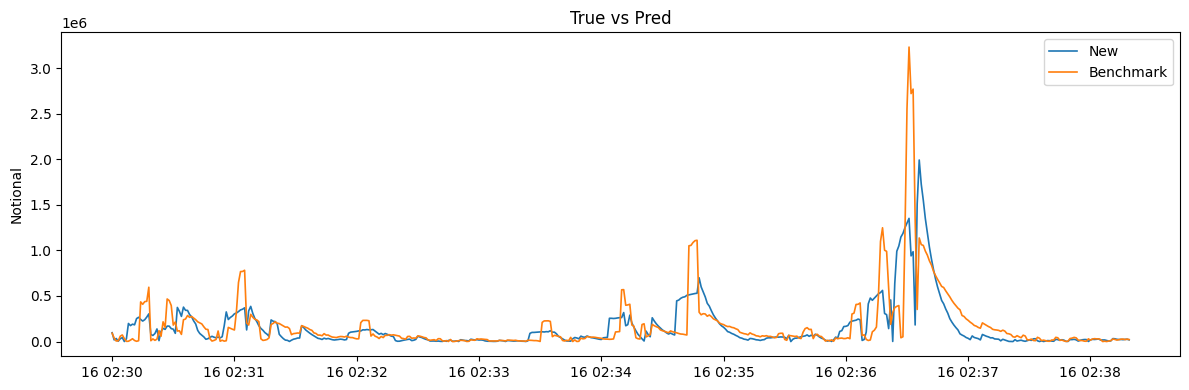

In [35]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 4))
plt.plot(diff_1.index[9000:9500], ((diff_1)[9000:9500]).abs(),  label='New', lw=1.2)
plt.plot(diff_2.index[9000:9500], (diff_2[9000:9500]).abs(),  label='Benchmark', lw=1.2)
plt.title('True vs Pred')
plt.ylabel('Notional')
plt.legend()
plt.tight_layout()
plt.show()